In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=10)

mnist_train = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

mnist_eval = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

In [4]:
batchsize = 32

train_loader = tud.DataLoader(mnist_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(mnist_eval, batch_size=batchsize, shuffle=True)

In [12]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.view(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        return x

In [13]:
class MyCnn(nn.Module):
    def __init__(self, out_sz, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (28x28)
        self.conv1_1 = nn.Conv2d(1, ch, kernel_size=3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)

        # (14x14)
        self.lin1 = nn.Linear(ch*2 * 14 * 14, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*2 * 14 * 14)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

In [14]:
from torchinfo import summary
testmodel = MyNn(28 * 28, 10, hidden_sz=512)
# testmodel = MyCnn(out_sz=10, ch=32)
test = mnist_train[0][0].float()
target = mnist_train[0][1].float()
print(target, testmodel(test))
summary(testmodel, (1, 1, 28, 28))

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]) tensor([[-5.8901, -1.1867,  1.9496,  7.3755, -7.0776, -5.0973,  2.8900,  9.1988,
          2.9105, -4.2920]], grad_fn=<AddmmBackward0>)


Layer (type:depth-idx)                   Output Shape              Param #
MyNn                                     [1, 10]                   --
├─Linear: 1-1                            [1, 512]                  401,920
├─Linear: 1-2                            [1, 512]                  262,656
├─Linear: 1-3                            [1, 512]                  262,656
├─Linear: 1-4                            [1, 10]                   5,130
Total params: 932,362
Trainable params: 932,362
Non-trainable params: 0
Total mult-adds (M): 0.93
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 3.73
Estimated Total Size (MB): 3.75

 20%|█████████▊                                       | 1/5 [00:02<00:10,  2.58s/it]

0.4373280107975006


 40%|███████████████████▌                             | 2/5 [00:05<00:07,  2.54s/it]

0.3910549283027649


 60%|█████████████████████████████▍                   | 3/5 [00:07<00:05,  2.51s/it]

0.35486507415771484


 80%|███████████████████████████████████████▏         | 4/5 [00:10<00:02,  2.49s/it]

0.36135169863700867


100%|█████████████████████████████████████████████████| 5/5 [00:12<00:00,  2.49s/it]

0.3574405610561371
CPU times: user 8.43 s, sys: 3.34 s, total: 11.8 s
Wall time: 12.5 s


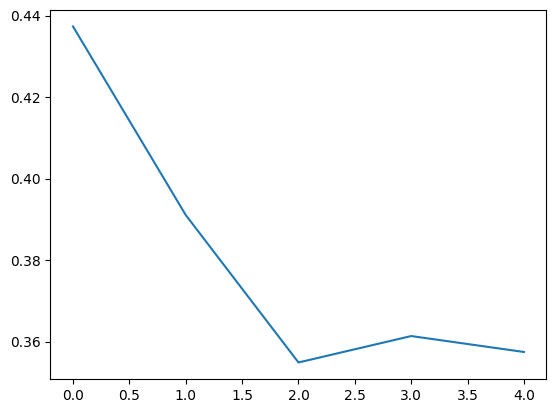

In [15]:
%%time
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = MyNn(28 * 28, 10, hidden_sz=1024).to(device)
# model = MyCnn(out_sz=10, ch=32).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
lossfn = nn.CrossEntropyLoss()
epochs = 5

loss_plot = []
for epoch in tqdm(range(epochs)):
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 10))
        loss.backward()
        optimizer.step()

    losses = []
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)
            loss = lossfn(outs, targets.view(-1, 10))
            losses.append(loss)
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

In [16]:
total = len(mnist_eval)
correct = 0
with torch.no_grad():
    for image, target in mnist_eval:
        pred = model(image.float().to(device))
        pred = F.softmax(pred, dim=1)
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

85.49% correct
